In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 19:31:37.912 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 19:31:38.235 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 19:31:38.236 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 19:31:38.244 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


2026-05-18 19:31:48.668 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'low_voltage_current_mirror.gds'


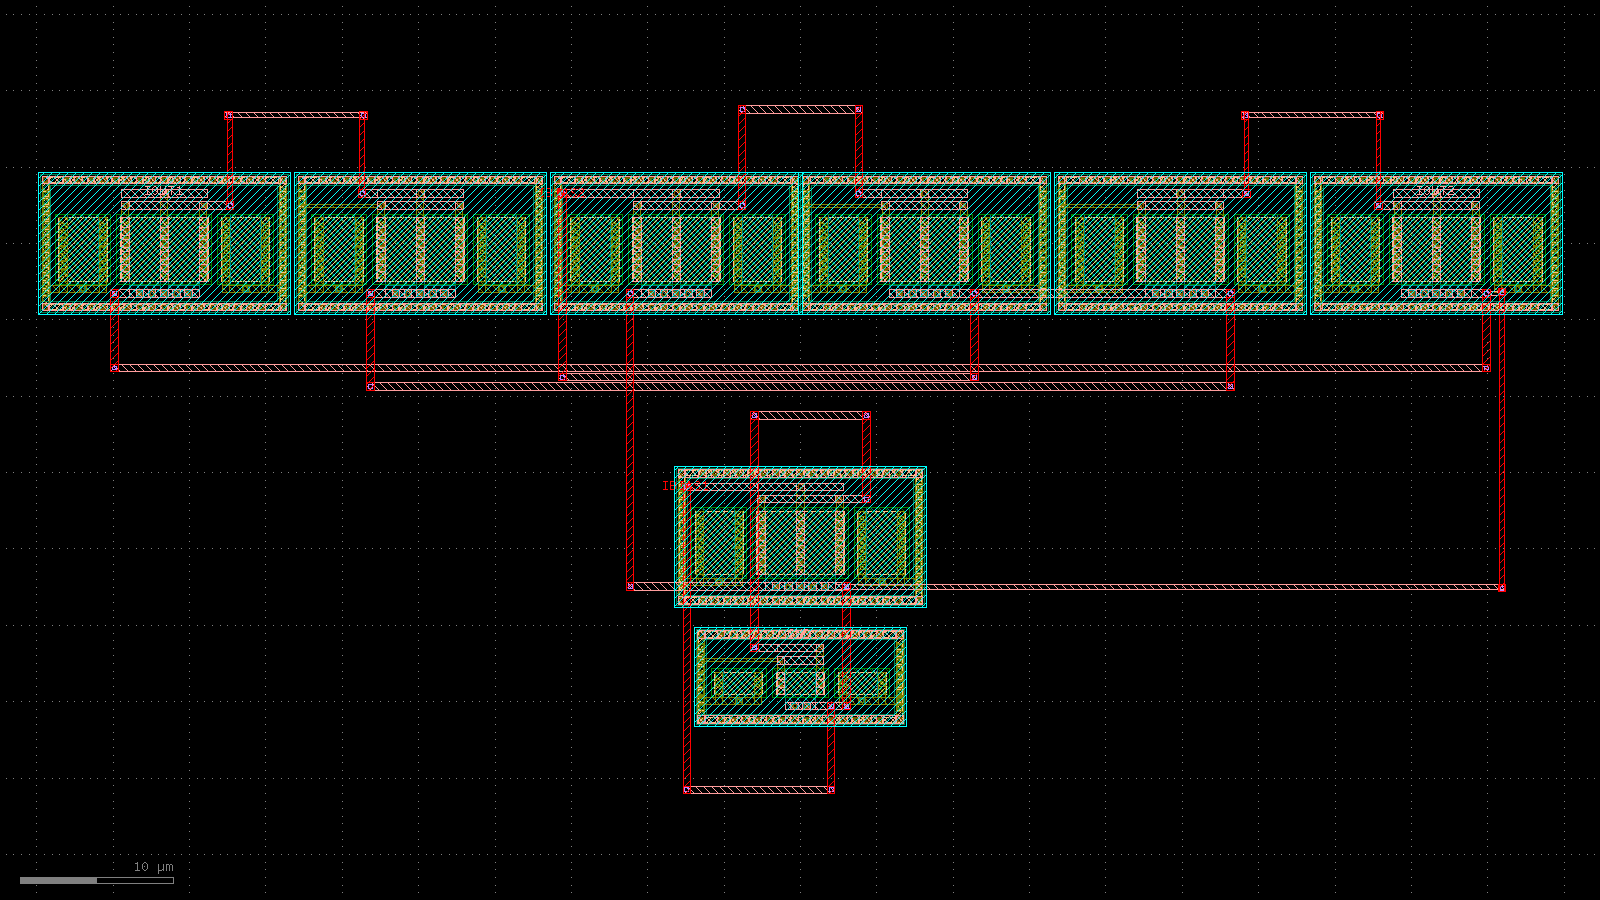

2026-05-18 19:31:48.739 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpizck61v5/Low_voltage_current_mirror.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:49.030 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpr_r57u_a/Low_voltage_current_mirror.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpizck61v5/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "Low_voltage_current_mirror".
[I


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "Low_voltage_current_mirror".
Extracting

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from glayout.pdk.mappedpdk import MappedPDK
from glayout.pdk.gf180_mapped import gf180_mapped_pdk
from gdsfactory.component import Component
from gdsfactory.component_reference import ComponentReference
from gdsfactory.cell import cell
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle
from glayout.primitives.fet import nmos, pmos, multiplier
from glayout.util.comp_utils import evaluate_bbox, prec_center, align_comp_to_port, prec_ref_center
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.util.port_utils import rename_ports_by_orientation
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.primitives.guardring import tapring
from glayout.util.port_utils import add_ports_perimeter
from glayout.spice.netlist import Netlist
from glayout.cells.elementary.FVF.fvf import fvf_netlist, flipped_voltage_follower  # Import from local ATLAS fvf.py
from glayout.primitives.via_gen import via_stack
from typing import Optional
from glayout.verification.evaluator_wrapper import run_evaluation


def add_lvcm_labels(lvcm_in: Component,
                pdk: MappedPDK
                ) -> Component:
	
    lvcm_in.unlock()

    met2_pin = (68,16)
    met2_label = (68,5)
    met3_pin = (69,16)
    met3_label = (69,5)
    # list that will contain all port/comp info
    move_info = list()
    # create labels and append to info list
    # gnd
    gndlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.5,0.5),centered=True).copy()
    gndlabel.add_label(text="GND",layer=pdk.get_glayer("met2_label"))
    move_info.append((gndlabel,lvcm_in.ports["M_1_B_tie_N_top_met_N"],None))
    
    #currentbias
    ibias1label = rectangle(layer=pdk.get_glayer("met3_pin"),size=(0.5,0.5),centered=True).copy()
    ibias1label.add_label(text="IBIAS1",layer=pdk.get_glayer("met3_label"))
    move_info.append((ibias1label,lvcm_in.ports["M_1_A_drain_bottom_met_N"],None))
    
    ibias2label = rectangle(layer=pdk.get_glayer("met3_pin"),size=(0.5,0.5),centered=True).copy()
    ibias2label.add_label(text="IBIAS2",layer=pdk.get_glayer("met3_label"))
    move_info.append((ibias2label,lvcm_in.ports["M_2_A_drain_bottom_met_N"],None))

    # output 
    output1label = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    output1label.add_label(text="IOUT1",layer=pdk.get_glayer("met2_label"))
    move_info.append((output1label,lvcm_in.ports["M_3_A_multiplier_0_drain_N"],None))
    
    output2label = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
    output2label.add_label(text="IOUT2",layer=pdk.get_glayer("met2_label"))
    move_info.append((output2label,lvcm_in.ports["M_4_A_multiplier_0_drain_N"],None))

    # move everything to position
    for comp, prt, alignment in move_info:
        alignment = ('c','b') if alignment is None else alignment
        compref = align_comp_to_port(comp, prt, alignment=alignment)
        lvcm_in.add(compref)
    return lvcm_in.flatten() 

def low_voltage_cmirr_netlist(bias_fvf: Component, cascode_fvf: Component, fet_1_ref: ComponentReference, fet_2_ref: ComponentReference, fet_3_ref: ComponentReference, fet_4_ref: ComponentReference) -> Netlist:
    
        netlist = Netlist(circuit_name='Low_voltage_current_mirror', nodes=['IBIAS1', 'IBIAS2', 'GND', 'IOUT1', 'IOUT2'])
        # Use netlist_obj for hierarchical netlist building
        netlist.connect_netlist(bias_fvf.info['netlist_obj'], [('VIN','IBIAS1'),('VBULK','GND'),('Ib','IBIAS1'),('VOUT','local_net_1')])
        netlist.connect_netlist(cascode_fvf.info['netlist_obj'], [('VIN','IBIAS1'),('VBULK','GND'),('Ib', 'IBIAS2'),('VOUT','local_net_2')])
        fet_1A_ref=netlist.connect_netlist(fet_2_ref.info['netlist'], [('D', 'IOUT1'),('G','IBIAS1'),('B','GND')])
        fet_2A_ref=netlist.connect_netlist(fet_4_ref.info['netlist'], [('D', 'IOUT2'),('G','IBIAS1'),('B','GND')])
        fet_1B_ref=netlist.connect_netlist(fet_1_ref.info['netlist'], [('G','IBIAS2'),('S', 'GND'),('B','GND')])
        fet_2B_ref=netlist.connect_netlist(fet_3_ref.info['netlist'], [('G','IBIAS2'),('S', 'GND'),('B','GND')])
        netlist.connect_subnets(
                fet_1A_ref,
                fet_1B_ref,
                [('S', 'D')]
                )
        netlist.connect_subnets(
                fet_2A_ref,
                fet_2B_ref,
                [('S', 'D')]
                )

        return netlist
   
@cell
def  low_voltage_cmirror(
        pdk: MappedPDK,
        width:  tuple[float,float] = (4.15,1.42),
        length: float = 2,
        fingers: tuple[int,int] = (2,1),
        multipliers: tuple[int,int] = (1,1),
        ) -> Component:
    """
    A low voltage N type current mirror. It has two input brnaches and two output branches. It consists of total 8 nfets, 7 of them have the same W/L. One nfet has width of w' = w/3(theoretcially)
    The default values are used to mirror 10uA.
    """
    #top level component
    top_level = Component("Low_voltage_N-type_current_mirror")

    #input branch 2
    cascode_fvf = flipped_voltage_follower(pdk, width=(width[0],width[0]), length=(length,length), fingers=(fingers[0],fingers[0]), multipliers=(multipliers[0],multipliers[0]), with_dnwell=False)
    cascode_fvf_ref = prec_ref_center(cascode_fvf)
    top_level.add(cascode_fvf_ref)
    
    #input branch 1
    bias_fvf = flipped_voltage_follower(pdk, width=(width[0],width[1]), length=(length,length), fingers=(fingers[0],fingers[1]), multipliers=(multipliers[0],multipliers[1]), placement="vertical", with_dnwell=False)
    bias_fvf_ref = prec_ref_center(bias_fvf)
    bias_fvf_ref.movey(cascode_fvf_ref.ymin - 2 - (evaluate_bbox(bias_fvf)[1]/2))
    top_level.add(bias_fvf_ref)

    #creating fets for output branches
    fet_1 = nmos(pdk, width=width[0], fingers=fingers[0], multipliers=multipliers[0], with_dummy=True, with_dnwell=False,  with_substrate_tap=False, length=length)
    fet_1_ref = prec_ref_center(fet_1)
    fet_2_ref = prec_ref_center(fet_1) 
    fet_3_ref = prec_ref_center(fet_1)
    fet_4_ref = prec_ref_center(fet_1)

    fet_1_ref.movex(cascode_fvf_ref.xmin - (evaluate_bbox(fet_1)[0]/2) - pdk.util_max_metal_seperation())
    fet_2_ref.movex(cascode_fvf_ref.xmin - (3*evaluate_bbox(fet_1)[0]/2) - 2*pdk.util_max_metal_seperation())
    fet_3_ref.movex(cascode_fvf_ref.xmax + (evaluate_bbox(fet_1)[0]/2) + pdk.util_max_metal_seperation())
    fet_4_ref.movex(cascode_fvf_ref.xmax + (3*evaluate_bbox(fet_1)[0]/2) + 2*pdk.util_max_metal_seperation())

    top_level.add(fet_1_ref)
    top_level.add(fet_2_ref)
    top_level.add(fet_3_ref)
    top_level.add(fet_4_ref)
 
    top_level << c_route(pdk, bias_fvf_ref.ports["A_multiplier_0_gate_E"], bias_fvf_ref.ports["B_gate_bottom_met_E"])
    top_level << c_route(pdk, cascode_fvf_ref.ports["A_multiplier_0_gate_W"], bias_fvf_ref.ports["A_multiplier_0_gate_W"])
    top_level << straight_route(pdk, cascode_fvf_ref.ports["B_gate_bottom_met_E"], fet_3_ref.ports["multiplier_0_gate_W"])
    
    #creating vias for routing
    viam2m3 = via_stack(pdk, "met2", "met3", centered=True)
    gate_1_via = top_level << viam2m3 
    gate_1_via.move(fet_1_ref.ports["multiplier_0_gate_W"].center).movex(-1)
    gate_2_via = top_level << viam2m3                                         
    gate_2_via.move(fet_2_ref.ports["multiplier_0_gate_W"].center).movex(-1)
    gate_3_via = top_level << viam2m3 
    gate_3_via.move(fet_3_ref.ports["multiplier_0_gate_E"].center).movex(1)
    gate_4_via = top_level << viam2m3 
    gate_4_via.move(fet_4_ref.ports["multiplier_0_gate_E"].center).movex(1)

    source_2_via = top_level << viam2m3
    drain_1_via = top_level << viam2m3
    source_2_via.move(fet_2_ref.ports["multiplier_0_source_E"].center).movex(1.5)
    drain_1_via.move(fet_1_ref.ports["multiplier_0_drain_W"].center).movex(-1)

    source_4_via = top_level << viam2m3
    drain_3_via = top_level << viam2m3
    source_4_via.move(fet_4_ref.ports["multiplier_0_source_W"].center).movex(-1)
    drain_3_via.move(fet_3_ref.ports["multiplier_0_drain_E"].center).movex(1.5)
    
    #routing
    top_level << straight_route(pdk, fet_2_ref.ports["multiplier_0_source_E"], source_2_via.ports["bottom_met_W"])
    top_level << straight_route(pdk, fet_1_ref.ports["multiplier_0_drain_W"], drain_1_via.ports["bottom_met_E"])
    top_level << straight_route(pdk, fet_4_ref.ports["multiplier_0_source_W"], source_4_via.ports["bottom_met_E"])
    top_level << straight_route(pdk, fet_3_ref.ports["multiplier_0_drain_E"], drain_3_via.ports["bottom_met_W"])
    top_level << c_route(pdk, source_2_via.ports["top_met_N"], drain_1_via.ports["top_met_N"], extension=0.5*evaluate_bbox(fet_1)[1], width1=0.32, width2=0.32, cwidth=0.32, e1glayer="met3", e2glayer="met3", cglayer="met2")
    top_level << c_route(pdk, source_4_via.ports["top_met_N"], drain_3_via.ports["top_met_N"], extension=0.5*evaluate_bbox(fet_1)[1], width1=0.32, width2=0.32, cwidth=0.32, e1glayer="met3", e2glayer="met3", cglayer="met2")
    top_level << c_route(pdk, bias_fvf_ref.ports["A_multiplier_0_gate_E"], gate_4_via.ports["bottom_met_E"], width1=0.32, width2=0.32, cwidth=0.32) 

 
    top_level << straight_route(pdk, fet_1_ref.ports["multiplier_0_gate_W"], gate_1_via.ports["bottom_met_E"])
    top_level << straight_route(pdk, fet_2_ref.ports["multiplier_0_gate_W"], gate_2_via.ports["bottom_met_E"])    
    top_level << straight_route(pdk, fet_3_ref.ports["multiplier_0_gate_E"], gate_3_via.ports["bottom_met_W"])
    top_level << straight_route(pdk, fet_4_ref.ports["multiplier_0_gate_E"], gate_4_via.ports["bottom_met_W"])

    top_level << c_route(pdk, gate_1_via.ports["top_met_S"], gate_3_via.ports["top_met_S"], extension=(1.2*width[0]+0.6), cglayer='met2')
    top_level << c_route(pdk, gate_2_via.ports["top_met_S"], gate_4_via.ports["top_met_S"], extension=(1.2*width[0]-0.6), cglayer='met2')
    
    top_level << straight_route(pdk, fet_1_ref.ports["multiplier_0_source_W"], fet_1_ref.ports["tie_W_top_met_W"], glayer1='met1', width=0.2)
    top_level << straight_route(pdk, fet_3_ref.ports["multiplier_0_source_W"], fet_3_ref.ports["tie_W_top_met_W"], glayer1='met1', width=0.2)
    

    top_level.add_ports(bias_fvf_ref.get_ports_list(), prefix="M_1_")
    top_level.add_ports(cascode_fvf_ref.get_ports_list(), prefix="M_2_")
    top_level.add_ports(fet_1_ref.get_ports_list(), prefix="M_3_B_")
    top_level.add_ports(fet_2_ref.get_ports_list(), prefix="M_3_A_")
    top_level.add_ports(fet_3_ref.get_ports_list(), prefix="M_4_B_")
    top_level.add_ports(fet_4_ref.get_ports_list(), prefix="M_4_A_")
    
    component = component_snap_to_grid(rename_ports_by_orientation(top_level))
    netlist_obj = low_voltage_cmirr_netlist(bias_fvf, cascode_fvf, fet_1_ref, fet_2_ref, fet_3_ref, fet_4_ref)
    component.info['netlist_obj'] = netlist_obj
    component.info['netlist'] = netlist_obj.generate_netlist()
    
    return component

if __name__=="__main__":
    #low_voltage_current_mirror = low_voltage_current_mirror(gf180_mapped_pdk)
    low_voltage_current_mirror = add_lvcm_labels(low_voltage_cmirror(gf180_mapped_pdk),gf180_mapped_pdk)
    pass # low_voltage_current_mirror.show()
    low_voltage_current_mirror.name = "Low_voltage_current_mirror"
    #pass # magic_drc_result = gf180_mapped_pdk.drc_magic(low_voltage_current_mirror, low_voltage_current_mirror.name)
    #pass # netgen_lvs_result = gf180_mapped_pdk.lvs_netgen(low_voltage_current_mirror, low_voltage_current_mirror.name)
    low_voltage_current_mirror_gds = low_voltage_current_mirror.write_gds("low_voltage_current_mirror.gds")
    pass # res = run_evaluation("low_voltage_current_mirror.gds", low_voltage_current_mirror.name, low_voltage_current_mirror)

# Show the generated GDS
show_gds("low_voltage_current_mirror.gds")

comp = low_voltage_current_mirror
# DRC with magic (graceful if magic not installed)
try:
    drc_result = gf180_mapped_pdk.drc_magic(comp, comp.name)
    print('DRC:', drc_result)
except Exception as e:
    print(f'DRC skipped: {e}')
# LVS with netgen (graceful if netgen not installed)
try:
    lvs_result = gf180_mapped_pdk.lvs_netgen(comp, comp.name)
    print('LVS:', lvs_result['result_str'])
except Exception as e:
    print(f'LVS skipped: {e}')


In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("low_voltage_current_mirror.gds", low_voltage_current_mirror.name, low_voltage_current_mirror)
    print(result)


--- Starting Comprehensive Evaluation for Low_voltage_current_mirror ---
Cleaning up intermediate files for component 'Low_voltage_current_mirror'...
  - Deleted: Low_voltage_current_mirror.res.ext
  - Deleted directory: Low_voltage_current_mirror_lvs_out
  - Deleted: Low_voltage_current_mirror.nodes
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:49.747 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpyyfg6z9j/Low_voltage_current_mirror.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmprvz5z8sh/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "Low_voltage_current_mirror".
[I


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "Low_voltage_current_mirror".
Extracting

[GDSTK] Unable to link hole in boolean operation.
/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/geometry/boolean.py:110: RuntimeWarning: Error in boolean operation.
  p = gdstk.boolean(


--- Evaluation complete. Results saved to Low_voltage_current_mirror_1.json ---
{'component_name': 'Low_voltage_current_mirror', 'timestamp': '2026-05-18T19:31:53.443408', 'drc_lvs_fail': True, 'drc': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irman/Gelochip/notebooks/datasets/low_voltage_cmirror/Low_voltage_current_mirror_drc_out/drc/Low_voltage_current_mirror/Low_voltage_current_mirror.rpt', 'summary': {'is_pass': False, 'total_errors': 12, 'error_details': [{'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.130um 3.915um 0.150um 4.035um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.130um 4.035um 0.150um 4.295um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.130um 4.295um 0.150um 4.415um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.130um -4.415um 0.150um -4.295um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.130um -4.295um 0.150um -4.035um'}, {'rule': 'Metal2 spacing < 0.28um (M2.2a)', 'details': '0.13

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(low_voltage_current_mirror, label='low_voltage_cmirror')


Circuit : Low_voltage_current_mirror
Nodes   : ['IBIAS1', 'IBIAS2', 'GND', 'IOUT1', 'IOUT2']

── DC Operating Point: low_voltage_cmirror ──

	Node                                  Voltage
	----                                  -------
	----	-------
	xdut.wire1                       2.702954e-01
	xdut.wire0                       2.702954e-01
	xdut.local_net_2                 2.690895e-01
	xdut.local_net_1                 2.696893e-01
	n_iout2                          1.650000e+00
	n_iout1                          1.650000e+00
	n_ibias2                         8.368381e-01
	n_ibias1                         1.203516e+00
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
